### Introduction to Data Pipeline

#### Import Libraries

In [4]:
import pandas as pd

#### Read Data

In [5]:
df = pd.read_csv("stud.csv")

In [6]:
print(df)

    Name   Age  Gender  Marks  Attendance
0   Asha  23.0  Female   85.0        90.0
1  Rahul  24.0    Male   78.0        85.0
2  Meera   NaN  Female   92.0        88.0
3  Arjun  23.0    male   70.0        80.0
4  Kiran  25.0  Female    NaN        95.0
5  Rahul  24.0    Male   78.0        85.0
6  Sneha  22.0  Female   88.0         NaN


#### Find Number of Missing Values

In [7]:
df.isna().sum()

Name          0
Age           1
Gender        0
Marks         1
Attendance    1
dtype: int64

#### Show only Missing Values

In [8]:
df[df.isna().any(axis=1)]

,Name,Age,Gender,Marks,Attendance
2,Meera,NaN,Female,92.0,88.0
4,Kiran,25.0,Female,NaN,95.0
6,Sneha,22.0,Female,88.0,NaN


#### Drop Missing Values

In [9]:
df_clean = df.dropna()

In [10]:
print(df_clean)

    Name   Age  Gender  Marks  Attendance
0   Asha  23.0  Female   85.0        90.0
1  Rahul  24.0    Male   78.0        85.0
3  Arjun  23.0    male   70.0        80.0
5  Rahul  24.0    Male   78.0        85.0


#### Finding out types of Data

In [11]:
print(df_clean.dtypes)

Name           object
Age           float64
Gender         object
Marks         float64
Attendance    float64
dtype: object


#### EDA

In [12]:
print(df_clean.describe())

            Age      Marks  Attendance
count   4.00000   4.000000    4.000000
mean   23.50000  77.750000   85.000000
std     0.57735   6.130525    4.082483
min    23.00000  70.000000   80.000000
25%    23.00000  76.000000   83.750000
50%    23.50000  78.000000   85.000000
75%    24.00000  79.750000   86.250000
max    24.00000  85.000000   90.000000


#### Histogram

In [13]:
import matplotlib.pyplot as plt

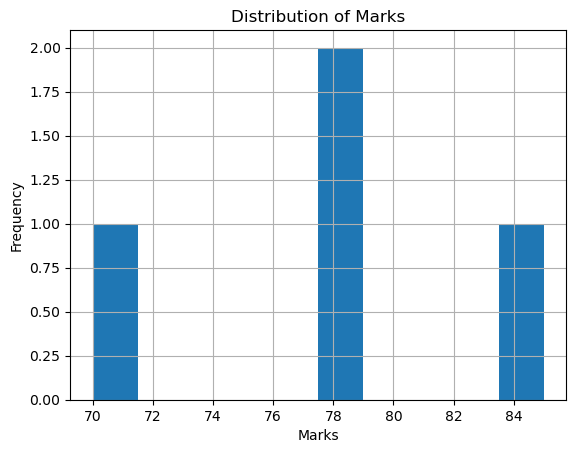

In [14]:
df_clean["Marks"].hist()

plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.title("Distribution of Marks")

plt.show()

#### Boxplot

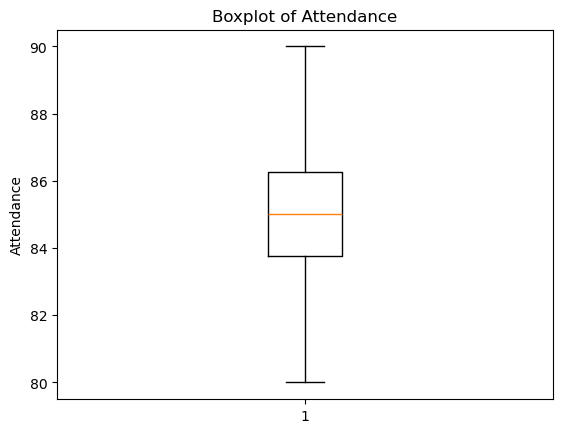

In [15]:
plt.boxplot(df_clean["Attendance"])

plt.ylabel("Attendance")
plt.title("Boxplot of Attendance")

plt.show()

/tmp/ipykernel_54772/1757533979.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean["Attendance"][0] = 9
/tmp/ipykernel_54772/1757533979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

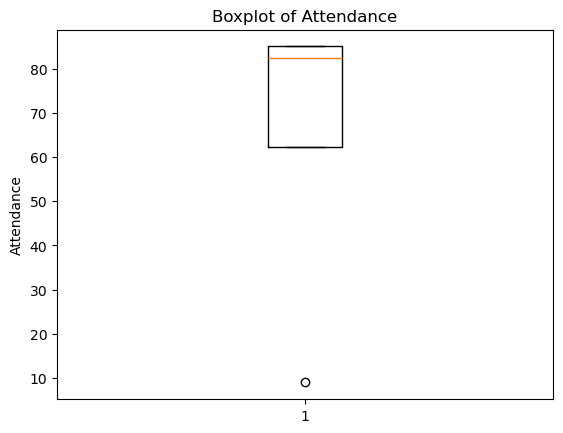

In [16]:
df_clean["Attendance"][0] = 9

plt.boxplot(df_clean["Attendance"])

plt.ylabel("Attendance")
plt.title("Boxplot of Attendance")

plt.show()

#### Find out correlation

In [17]:
corr_matrix = df_clean.corr(numeric_only=True)

print(corr_matrix.round(3))

              Age  Marks  Attendance
Age         1.000  0.047       0.628
Marks       0.047  1.000      -0.748
Attendance  0.628 -0.748       1.000


#### Feature Selection

In [18]:
X = df_clean[["Age", "Attendance","Gender"]]
y = df_clean["Marks"]

In [19]:
print(X)

    Age  Attendance  Gender
0  23.0         9.0  Female
1  24.0        85.0    Male
3  23.0        80.0    male
5  24.0        85.0    Male


In [20]:
print(y)

0    85.0
1    78.0
3    70.0
5    78.0
Name: Marks, dtype: float64
